<a href="https://colab.research.google.com/github/Daniel-EDC/StudentPerformanceModel/blob/main/StudentPredictionPlusExtra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset has 15 columns and 2392 students
df = pd.read_csv("Student_performance_data _.csv")

#Note, this is to delete Gradeclass if GPA is what I am after
df = df.drop(columns=["GradeClass"]) #It is the opposite of GPA

#Other notes: Ethnicity (0=Caucasian, 1=African American, 2=Asian, 3=Other);
#             ParentalEducation (0=None, 1=High School, 2=Some College, 3=Bachelor’s, 4=Higher); ParentalSupport (0=None, 1=Low, 2=Moderate, 3=High, 4=Very High).

# Head of dataset
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (2392, 14)

Columns:
 Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA'],
      dtype='object')

Data Types:

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
dtype: object


In [ ]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values in each Column:\n")
print(missing_values)

#no missing values

Missing Values in each Column:

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
dtype: int64


In [ ]:
print("Number of duplicate rows is:", df.duplicated().sum())# no duplicate rows

Number of duplicate rows is: 0


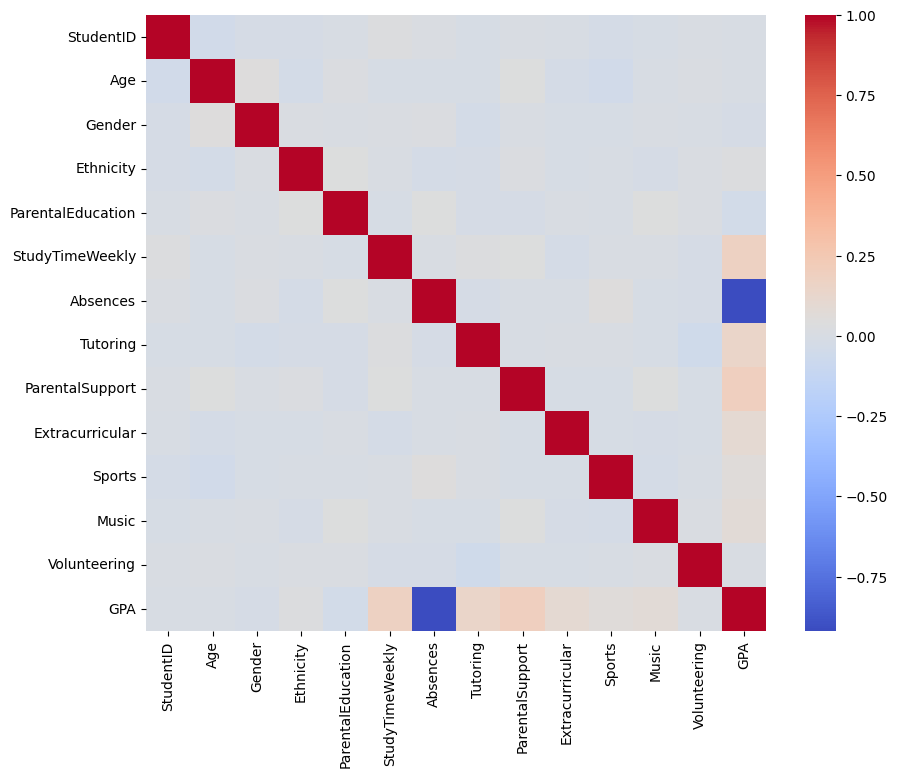

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# this is a correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

#this shows that Abscneces is blue beucase its bad(so look for no), and tutoring, studytime, and parental support are redish

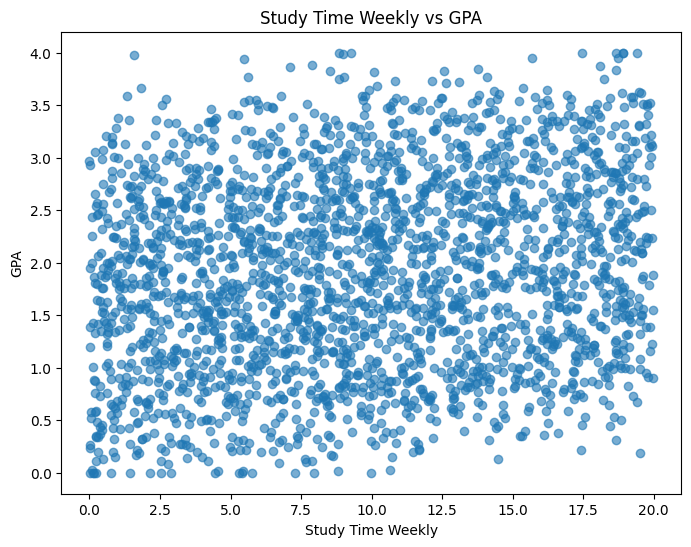

In [ ]:
#practice scattergraph:

import matplotlib.pyplot as plt #imot

plt.figure(figsize=(8,6))
plt.scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.6)
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.title('Study Time Weekly vs GPA')
plt.show()

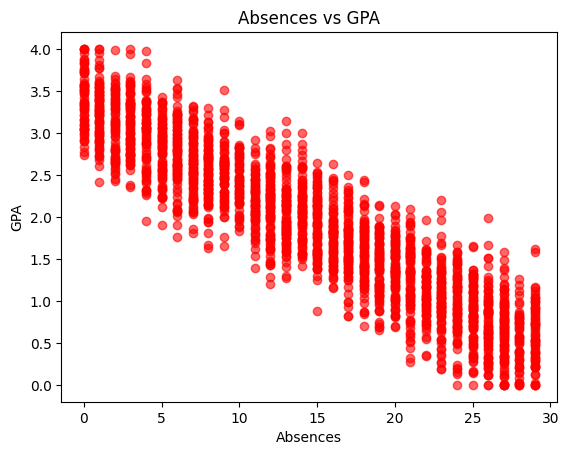

In [ ]:
# The best one is absences

plt.scatter(df['Absences'], df['GPA'], alpha=0.6, color='red')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.title('Absences vs GPA')
plt.show()

#this one is better becuase it shows a pattern and relationship

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(df[['Absences', 'StudyTimeWeekly']], df['GPA'])
print("Many Absences")

# Example: 10 absences, 5 hours study/week
reg.predict([[6, 5]])

Many Absences


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.61133149])

In [ ]:
# Example: 2 absences, 15 hours study/week
reg.predict([[2, 15]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.31366868])

In [ ]:
from sklearn.metrics import r2_score

# Predictions on the dataset (or you can split into train/test if you want)
y_pred = reg.predict(df[['Absences', 'StudyTimeWeekly']])

# R² Score
r2 = r2_score(df['GPA'], y_pred)

print("Linear Regression R²:", r2)
print("slightly better then 0.84 with just absences.")

Linear Regression R²: 0.8804274736679993


In [ ]:
print("Now for the KNN Area.")

Now for the KNN Area.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Feature (input) and Target (output)
X = df[['Absences', 'StudyTimeWeekly']]
y = df['GPA']

# Split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Create KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(x_train, y_train)

# Predict GPA values
y_pred = knn.predict(x_test)

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.11617843590200887


In [ ]:
# Example predictions
print("Many Absences and few hours")
#print(knn.predict([[10]]))
print(knn.predict([[10, 5]]))

Many Absences
[2.18185365]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [ ]:
print("Few Absences and many hours")
print(knn.predict([[1, 15]]))

Few Absences and many hours
[3.31417563]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


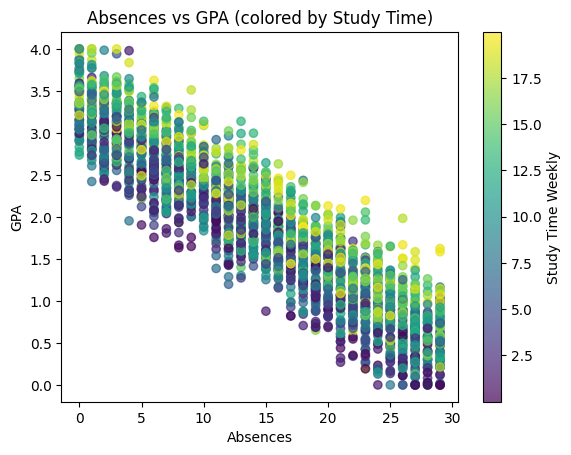

In [ ]:
plt.scatter(df['Absences'], df['GPA'],
            c=df['StudyTimeWeekly'], cmap='viridis', alpha=0.7)

plt.colorbar(label='Study Time Weekly')
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.title("Absences vs GPA (colored by Study Time)")
plt.show()

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

df['target'] = pd.cut(df['GPA'],
                     bins=[-0.01, 1, 2, 3, 4.0],
                     labels=[0, 1, 2, 3])

# Features (NOW includes StudyTimeWeekly)
x = df[['Absences', 'StudyTimeWeekly']]
y = df['target']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1
)

# Scale data (important for KNN)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)



KNeighborsClassifier()

In [ ]:
# Predict
y_pred = knn.predict(x_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 74  21   0   0]
 [ 23 126  19   0]
 [  0  26 119  19]
 [  0   0  20  32]]


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Better metric for classification
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.78      0.77        95
           1       0.73      0.75      0.74       168
           2       0.75      0.73      0.74       164
           3       0.63      0.62      0.62        52

    accuracy                           0.73       479
   macro avg       0.72      0.72      0.72       479
weighted avg       0.73      0.73      0.73       479

Accuracy: 0.732776617954071


In [ ]:
# Better metric for classification
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.732776617954071


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Slightly better than the lone R^2 of just absences")

MSE: 0.267223382045929
R^2: 0.6835738320843913
Slightly better than the lone R^2 of just absences


In [ ]:
# Import required libraries for data handling, visualization, and ML
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Machine learning tools
from sklearn.cluster import KMeans                # K-Means clustering (unsupervised learning)
from sklearn import linear_model                 # Linear regression model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Load again
df = pd.read_csv('Student_performance_data _.csv')

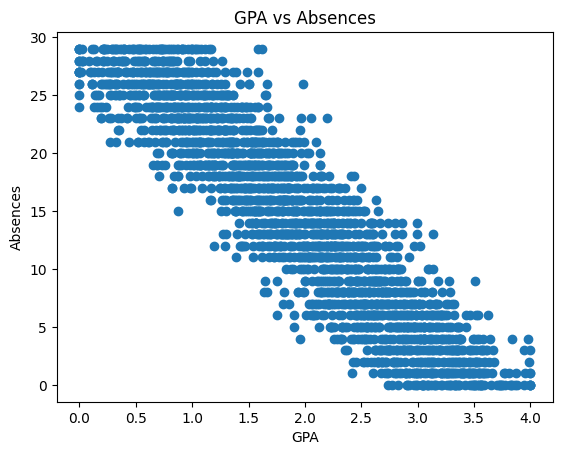

In [ ]:
# Scatter plot to visualize relationship between GPA and Absences
plt.scatter(df.GPA, df.Absences)
plt.xlabel("GPA")
plt.ylabel("Absences")
plt.title("GPA vs Absences")
plt.show()

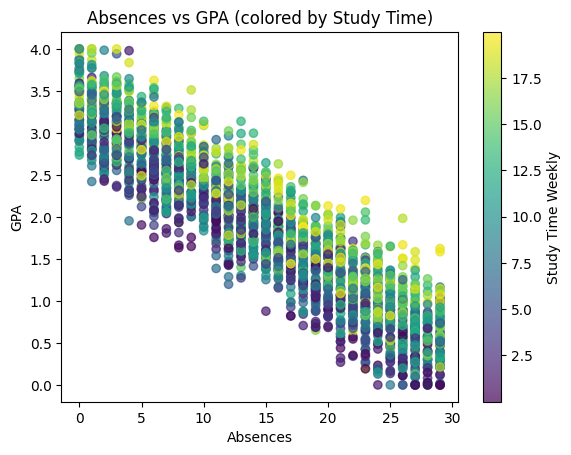

In [ ]:
plt.scatter(df['Absences'], df['GPA'],
            c=df['StudyTimeWeekly'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Study Time Weekly')

plt.xlabel("Absences")
plt.ylabel("GPA")
plt.title("Absences vs GPA (colored by Study Time)")
plt.show()

In [ ]:
# Features for clustering (NOW 2D)
X = df[['Absences', 'StudyTimeWeekly']]

# Target
y = df['GPA']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# K-Means clustering
km = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = km.fit_predict(X_scaled)

X_clustered = df[['Absences', 'StudyTimeWeekly', 'Cluster']]

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clustered,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Create linear regression model
reg = linear_model.LinearRegression()

# Train model using Absences + Cluster
reg.fit(X_train, y_train)

# Predict GPA on test data
y_pred = reg.predict(X_test)

In [ ]:
# New student: 5 absences, 10 study hours/week
new_data = pd.DataFrame({
    'Absences': [5],
    'StudyTimeWeekly': [10]
})

# Scale using same scaler
new_data_scaled = scaler.transform(new_data)

# Predict cluster
new_cluster = km.predict(new_data_scaled)

# Combine features
new_data_clustered = pd.DataFrame({
    'Absences': [5],
    'StudyTimeWeekly': [10],
    'Cluster': new_cluster
})

# Predict GPA
new_gpa_pred = reg.predict(new_data_clustered)

print("Predicted GPA:", new_gpa_pred[0])

Predicted GPA: 2.855812464594935


Score: 0.8775059560554224


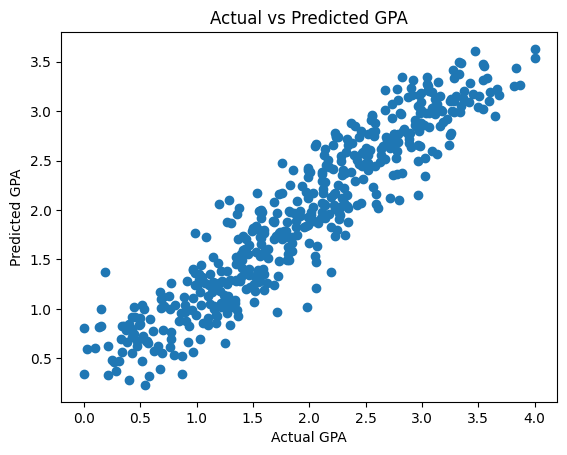

In [ ]:
#Evaluation
score = reg.score(X_test, y_test)
print("Score:", score)
print("Only slightly better then just absences.")

plt.scatter(y_test, y_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()

In [ ]:
def gpa_label(gpa):
    if gpa < 2.5:
        return 0
    elif gpa < 3.5:
        return 1
    else:
        return 2

df['GPA_Label'] = df['GPA'].apply(gpa_label)

# Compare actual GPA categories with clusters
cm = confusion_matrix(df['GPA_Label'], df['Cluster'])
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[743 717 226]
 [156   5 468]
 [  4   0  73]]


In [ ]:
# Detailed classification metrics
print("\nClassification Report:")
print(classification_report(df['GPA_Label'], df['Cluster']))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.44      0.57      1686
           1       0.01      0.01      0.01       629
           2       0.10      0.95      0.17        77

    accuracy                           0.34      2392
   macro avg       0.31      0.47      0.25      2392
weighted avg       0.58      0.34      0.41      2392



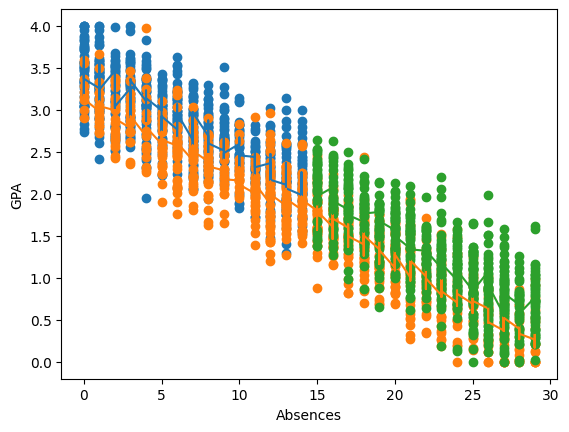

In [ ]:
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]

    X_cluster = cluster_data[['Absences', 'StudyTimeWeekly', 'Cluster']] #now study time
    y_cluster = cluster_data['GPA']

    sorted_idx = cluster_data['Absences'].argsort()
    X_sorted = X_cluster.iloc[sorted_idx]
    y_pred_cluster = reg.predict(X_sorted)

    plt.scatter(cluster_data['Absences'], y_cluster, label=f'Cluster {cluster}')
    plt.plot(X_sorted['Absences'], y_pred_cluster)

plt.xlabel("Absences")
plt.ylabel("GPA")
plt.legend()
plt.show()